# Part C — Where the asset class is going (closing slides)

Thin driver notebook: all logic lives in `src/future/`. Every claim about the future is grounded in a scraped forward-looking dataset — registrations, rulemaking, litigation, product pipeline, retail attention. No punditry, no forecasting model.

- **Product pipeline** (`scrape_product_pipeline.py`, `analysis_pipeline.py`): EDGAR full-text search for fund-registration filings (N-2/485APOS/N-1A) mentioning CLOs — 293 filings, 102 distinct sponsors observed.
- **Composition shift** (`scrape_mm_share.py`, `analysis_composition_shift.py`): **not** the originally planned market-wide BSL-vs-MM new-issue share — Section 5's presale corpus (the intended source) is empty (S&P Akamai-walled, Fitch client-rendered). Reuses this project's own NPORT-P CLO-equity holdings instead, classified by a hand-curated middle-market manager-shelf keyword list — a narrower lens (two funds' own books), labeled as such.
- **Legal regime** (`scrape_litigation.py`, `analysis_legal_regime.py`): CourtListener/RECAP docket counts for the LME-era's public query terms (uptier, drop-down, liability management exercise). The planned joins against presale LME vocabulary and realized downgrade actions are both gapped for the same Section 5 reason — reported, not dropped.
- **Rulemaking**: `scrape_rulemaking.py` (Federal Register API) doubles as Section 6 v2's regulator-corpus input and this section's rulemaking/comment-controversy proxy.
- **Retail attention**: Google Trends (`scrape_trends.py`, via pytrends) — the one genuinely multi-year input in the maturation scorecard.
- **Market maturation scorecard** (`analysis_maturation_scorecard.py`): built as a **current-state snapshot**, not an indexed multi-year trend — most inputs (ETF AUM, TRACE volume, EFA holder composition) are themselves single-date snapshots elsewhere in this project; only Trends has real multi-year history.
- **Scenario watchlist** (`analysis_scenarios.py`): three macro scenarios, each paired with which already-built series in this project would move first — a monitoring map, explicitly not a forecast.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from IPython.display import Image, display

from src.future import (
    scrape_product_pipeline, scrape_mm_share, scrape_litigation, scrape_rulemaking,
    scrape_trends, scrape_etf_filings_options,
    analysis_pipeline, analysis_composition_shift, analysis_legal_regime,
    analysis_maturation_scorecard, analysis_scenarios,
    viz_pipeline, viz_composition, viz_legal, viz_scorecard, viz_watchlist,
    ledger,
)


/Users/zinuoshi/clo-atlas/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Scrape (raw -> interim)

In [2]:
RUN_SCRAPE = False
if RUN_SCRAPE:
    scrape_product_pipeline.run()
    scrape_mm_share.run()          # classifies cef_clo_positions.parquet, no new network calls
    scrape_litigation.run()
    scrape_rulemaking.run()
    scrape_trends.run()
    scrape_etf_filings_options.run()


## Analysis (interim -> final)

In [3]:
pipeline = analysis_pipeline.run()
composition_shift = analysis_composition_shift.run()
legal_regime = analysis_legal_regime.run()
maturation_scorecard = analysis_maturation_scorecard.run()
scenarios = analysis_scenarios.run()


## Viz (final -> figures/)

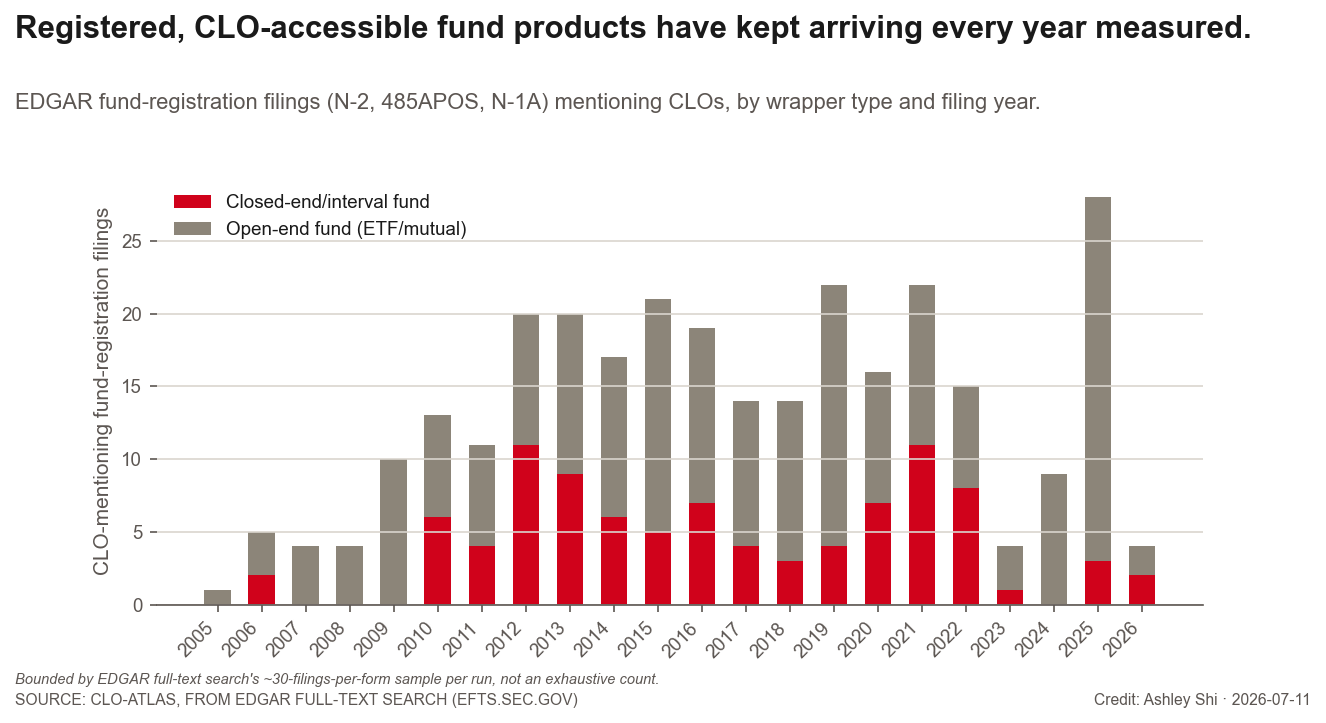

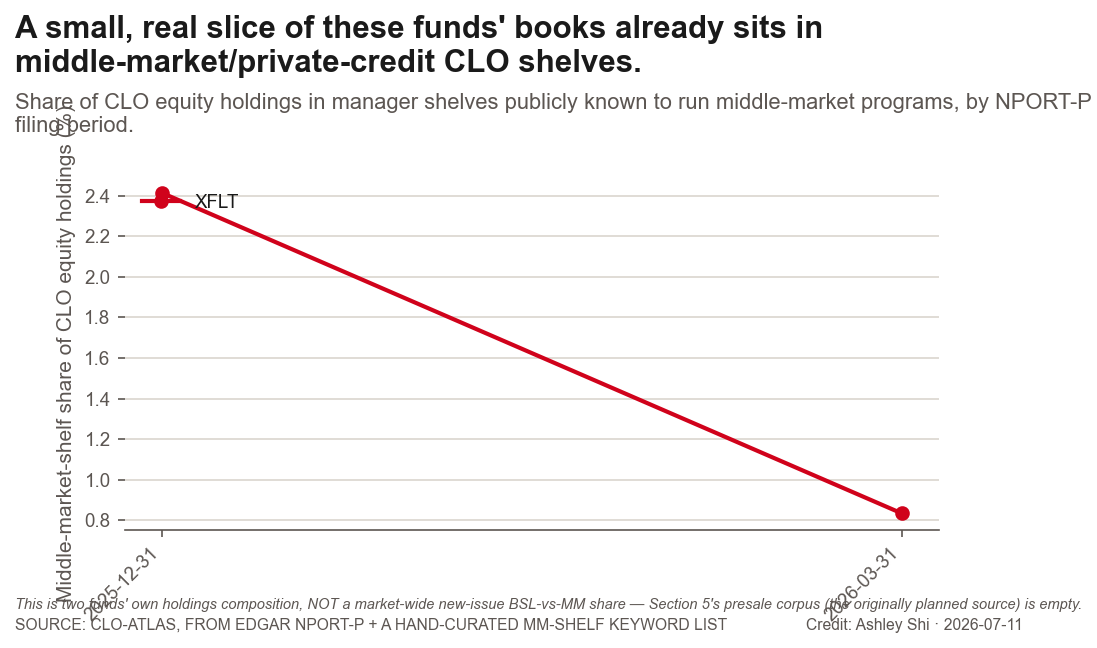

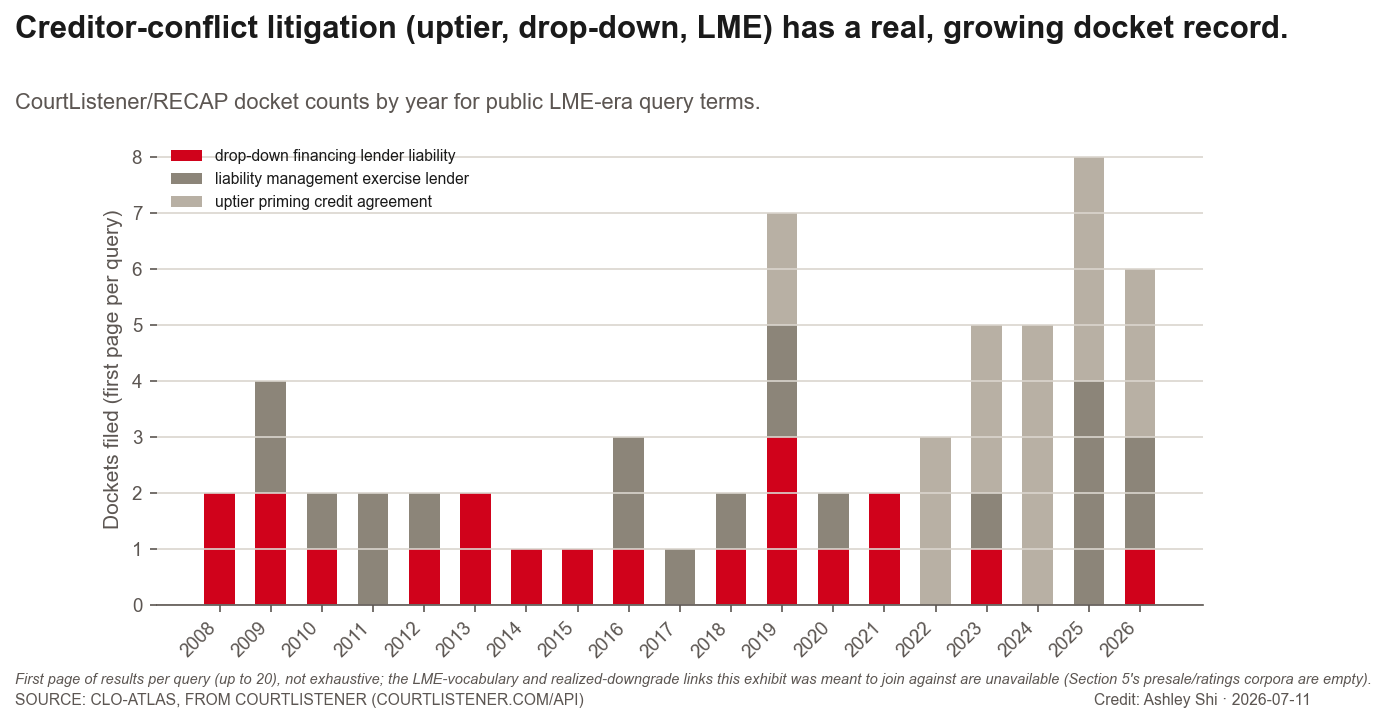

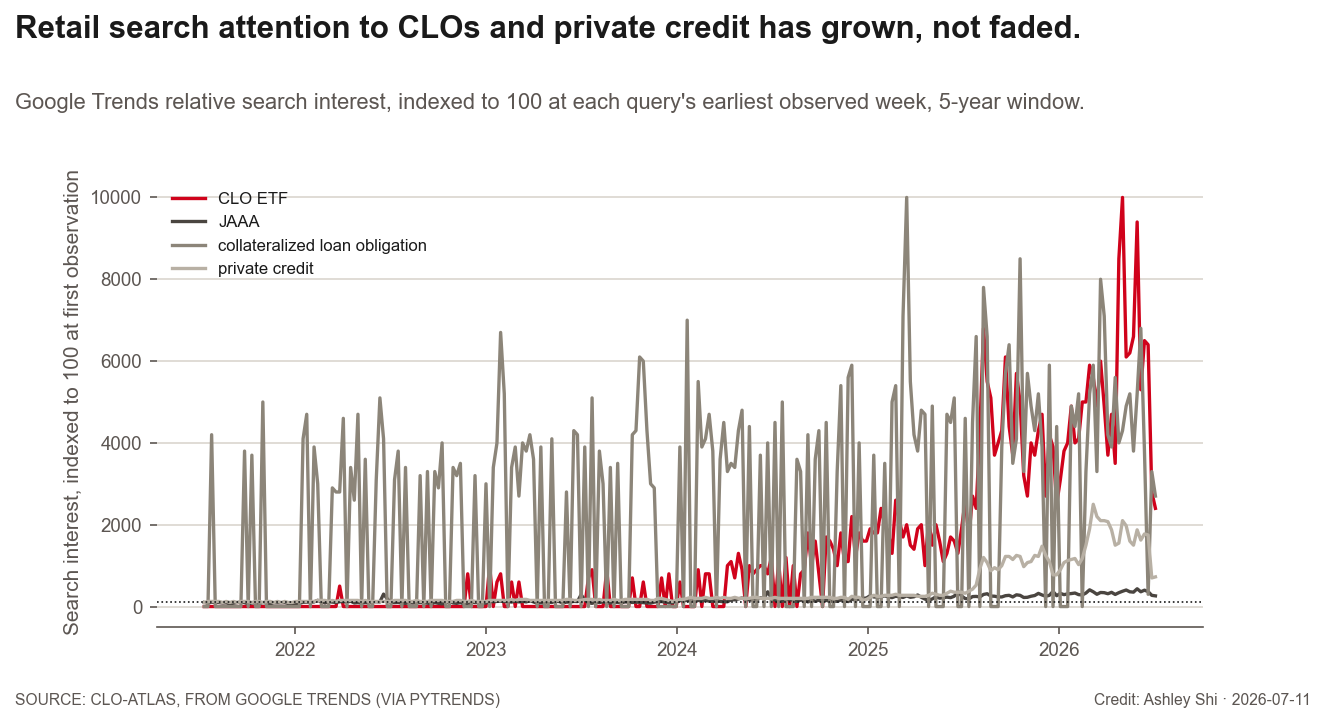

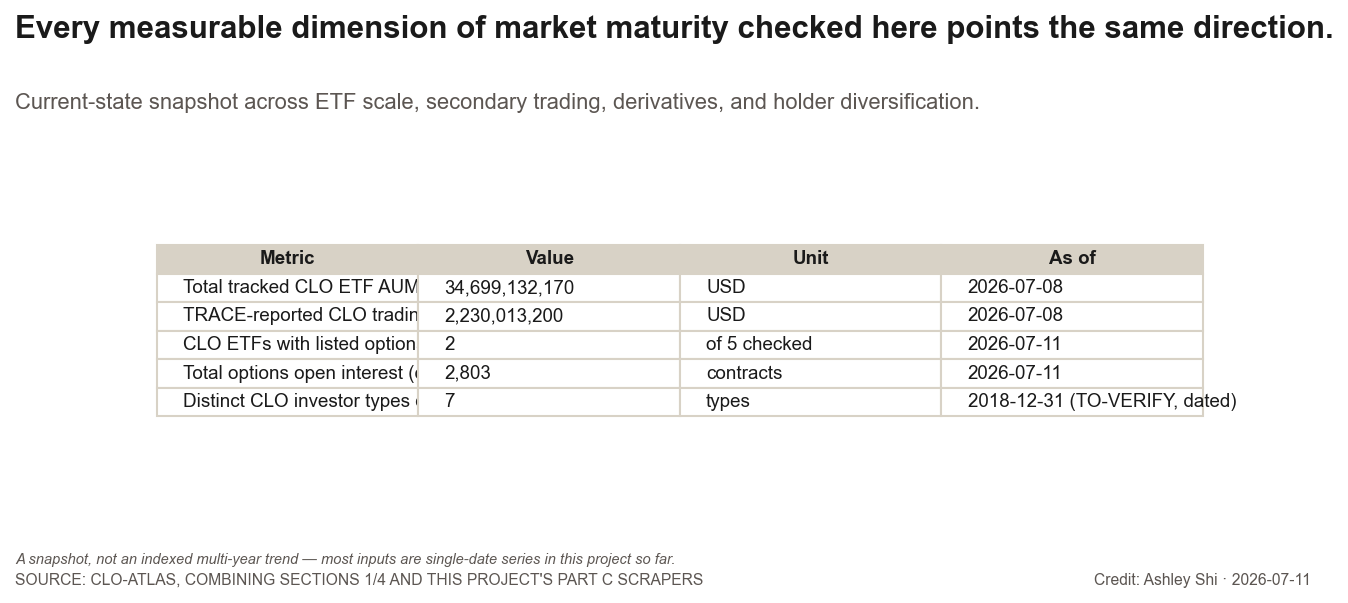

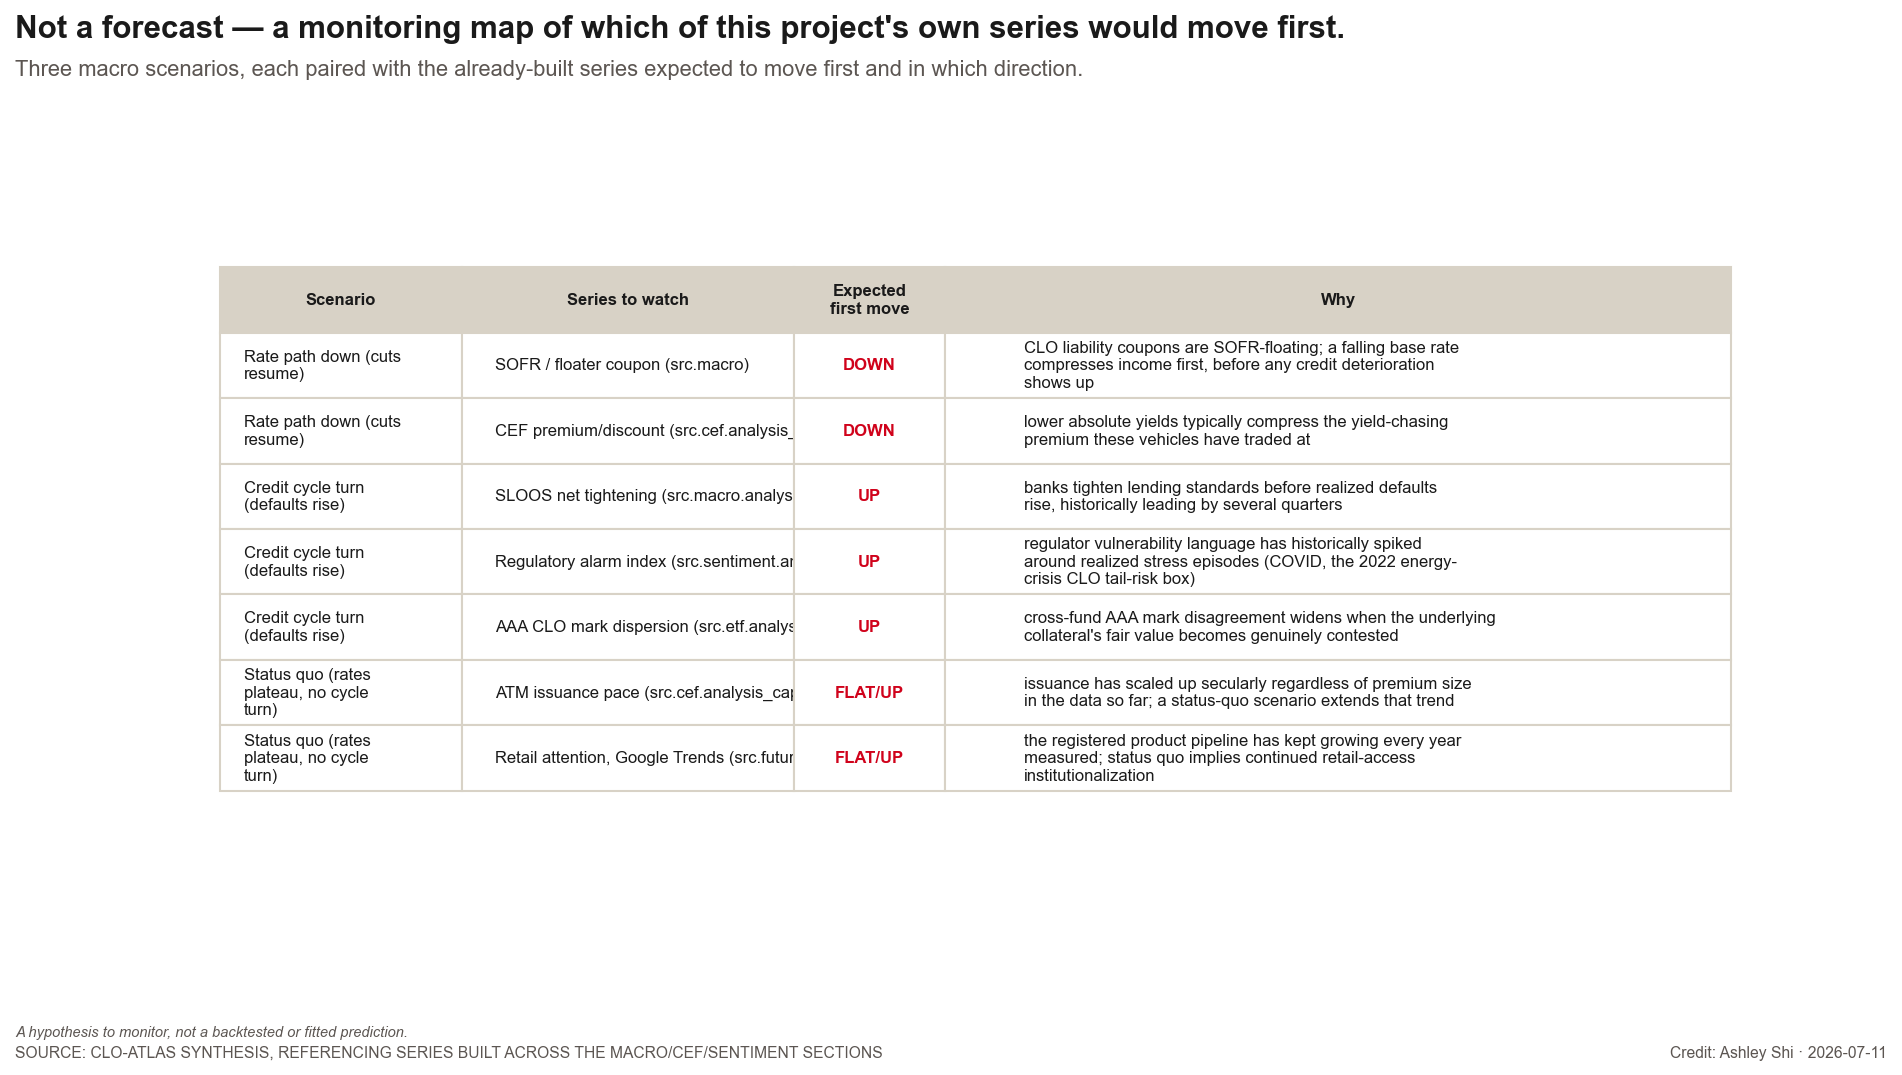

In [4]:
viz_pipeline.run()
viz_composition.run()
viz_legal.run()
viz_scorecard.run()
viz_watchlist.run()


## Exhibits

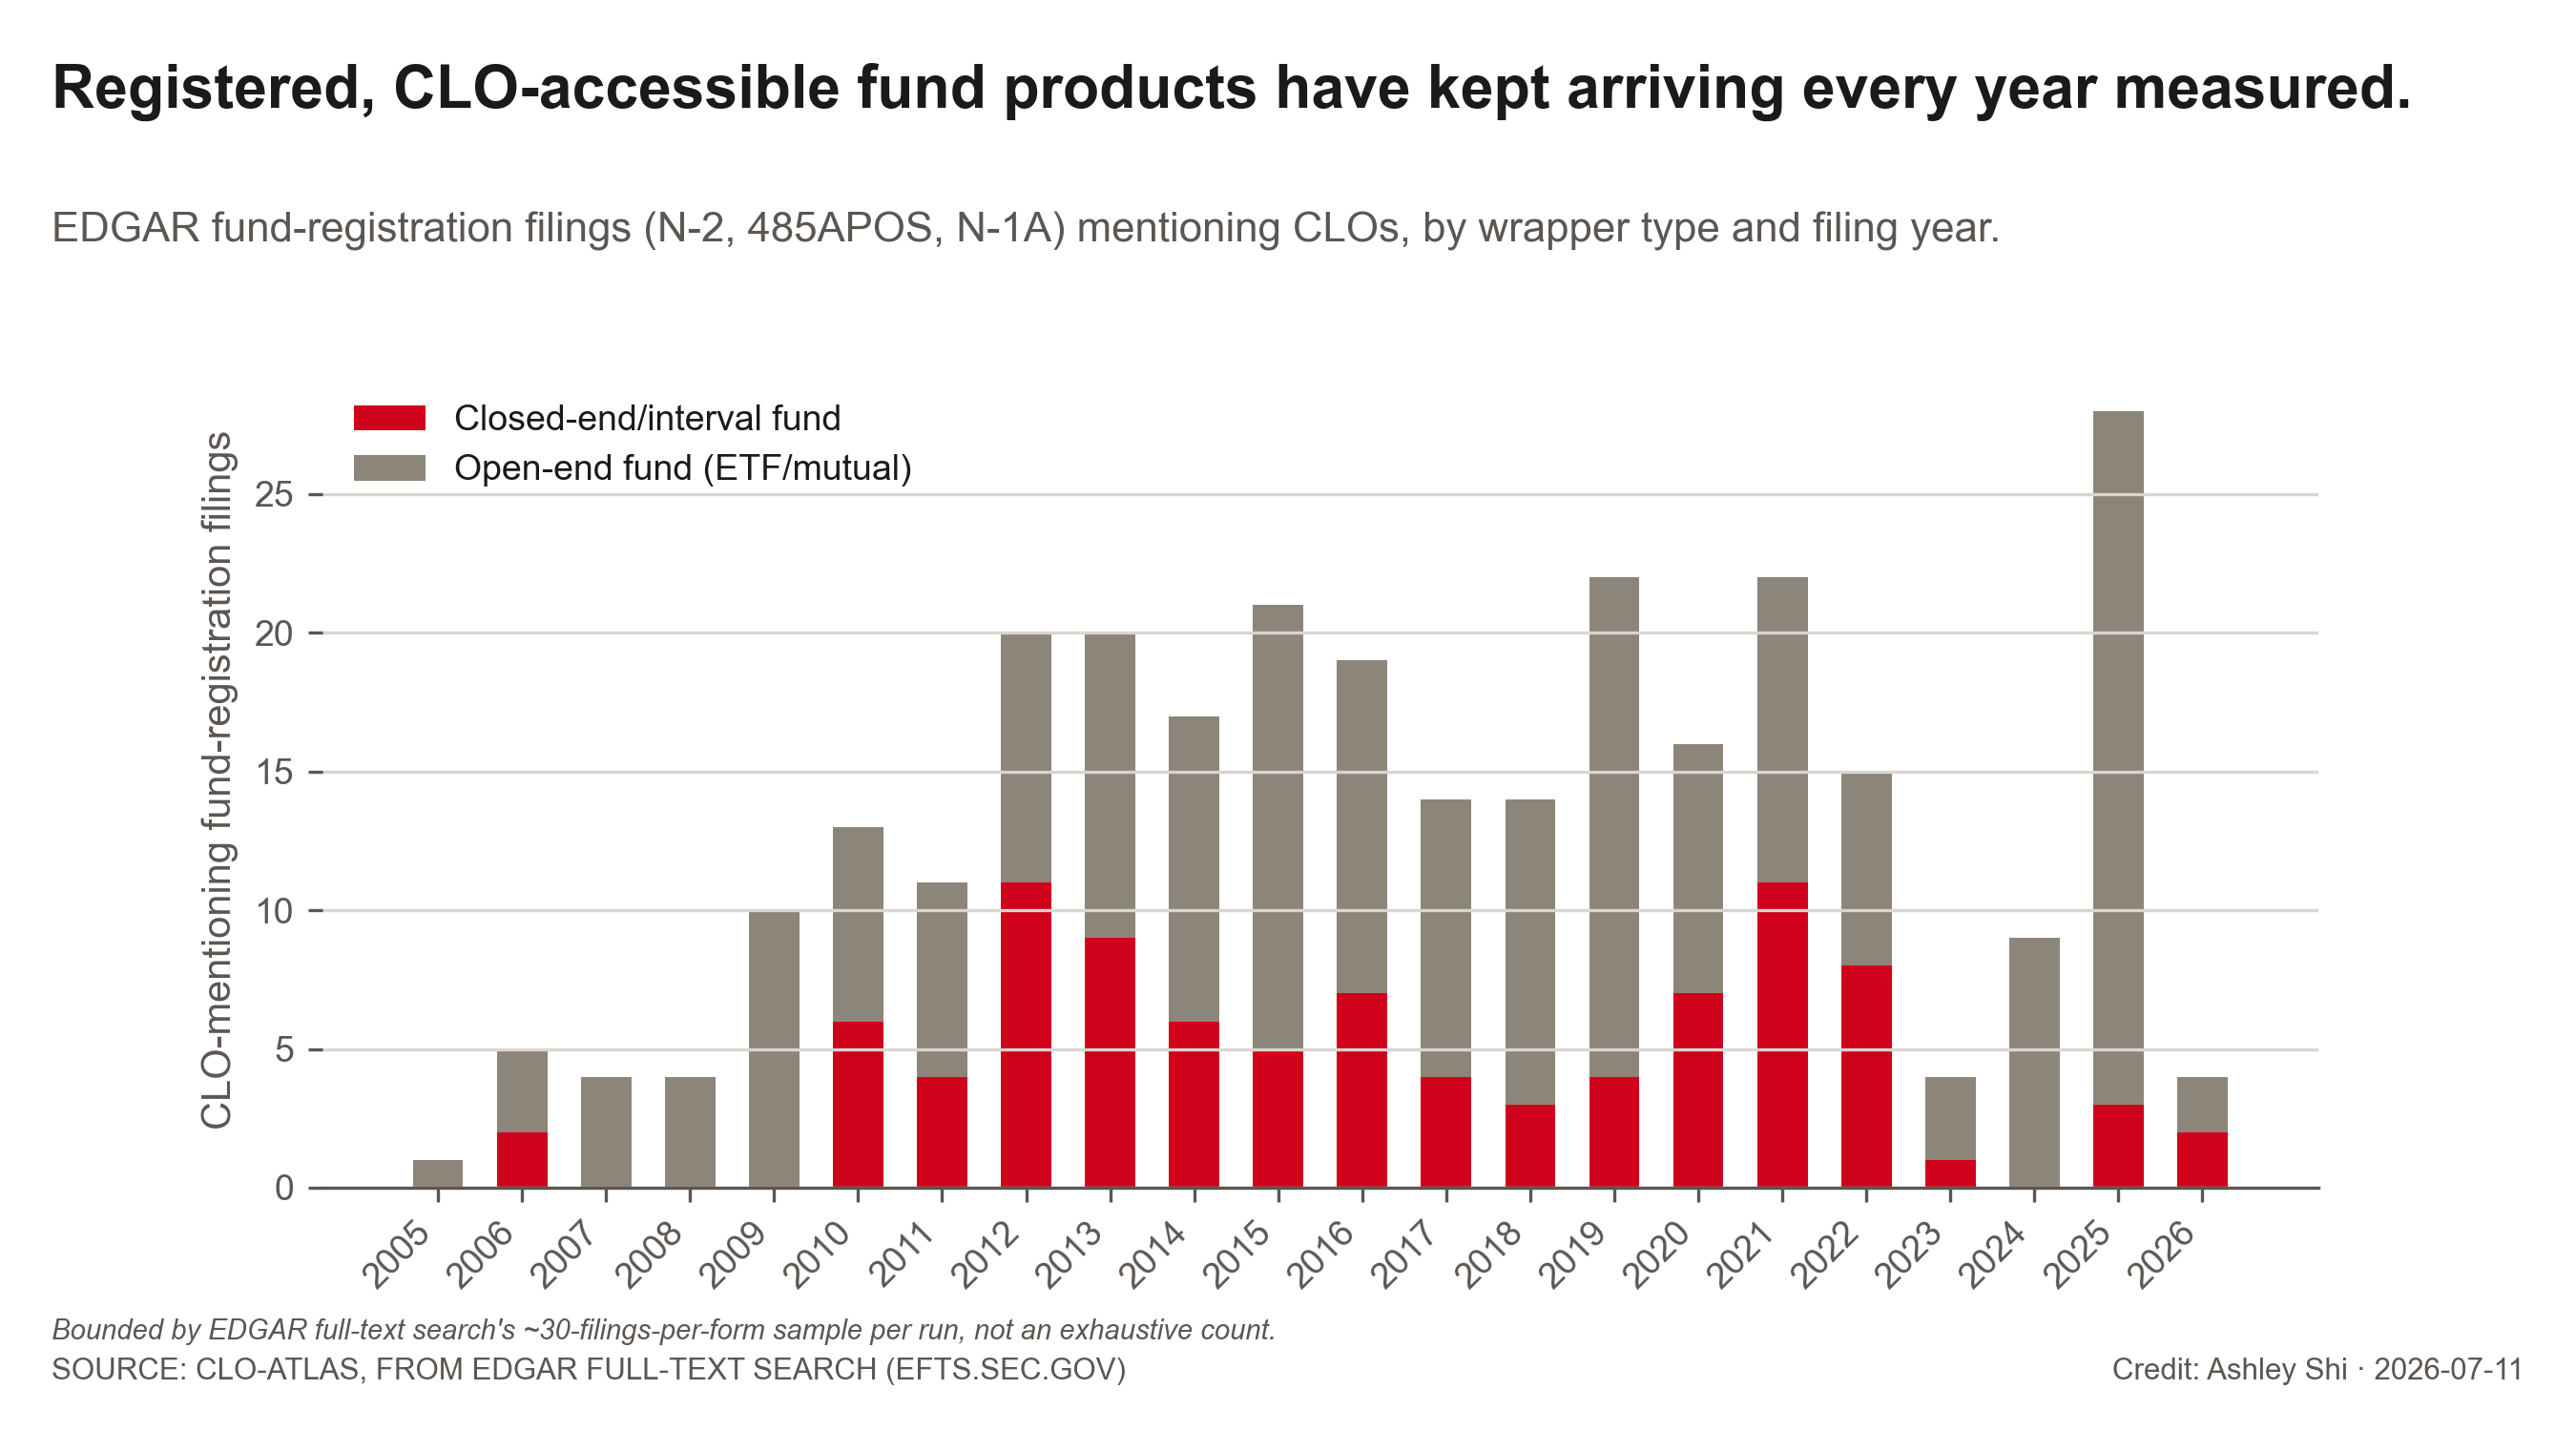

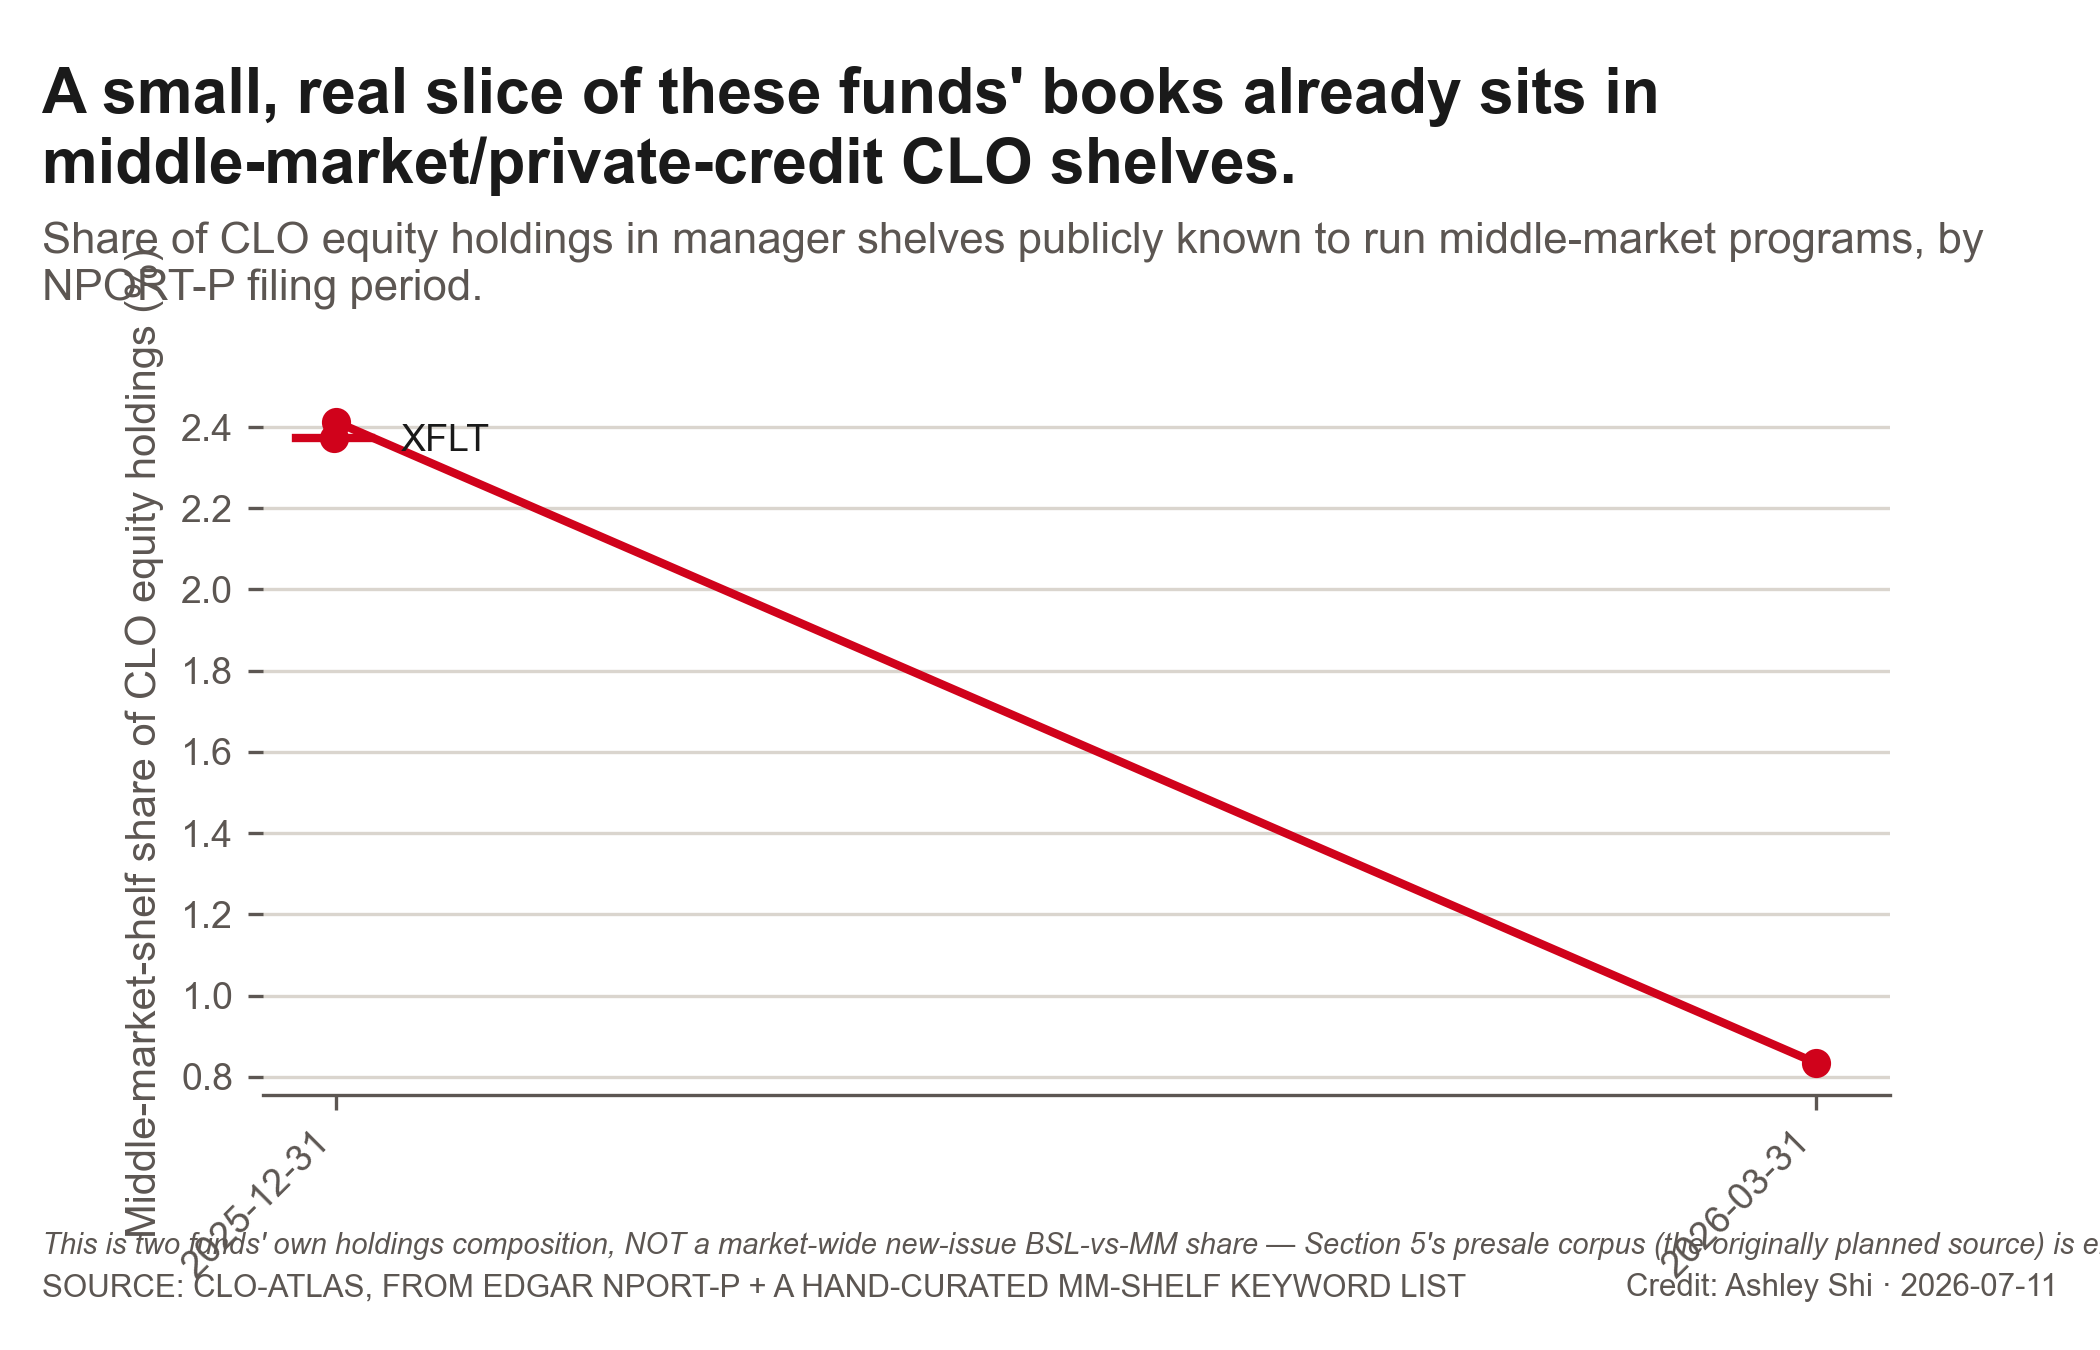

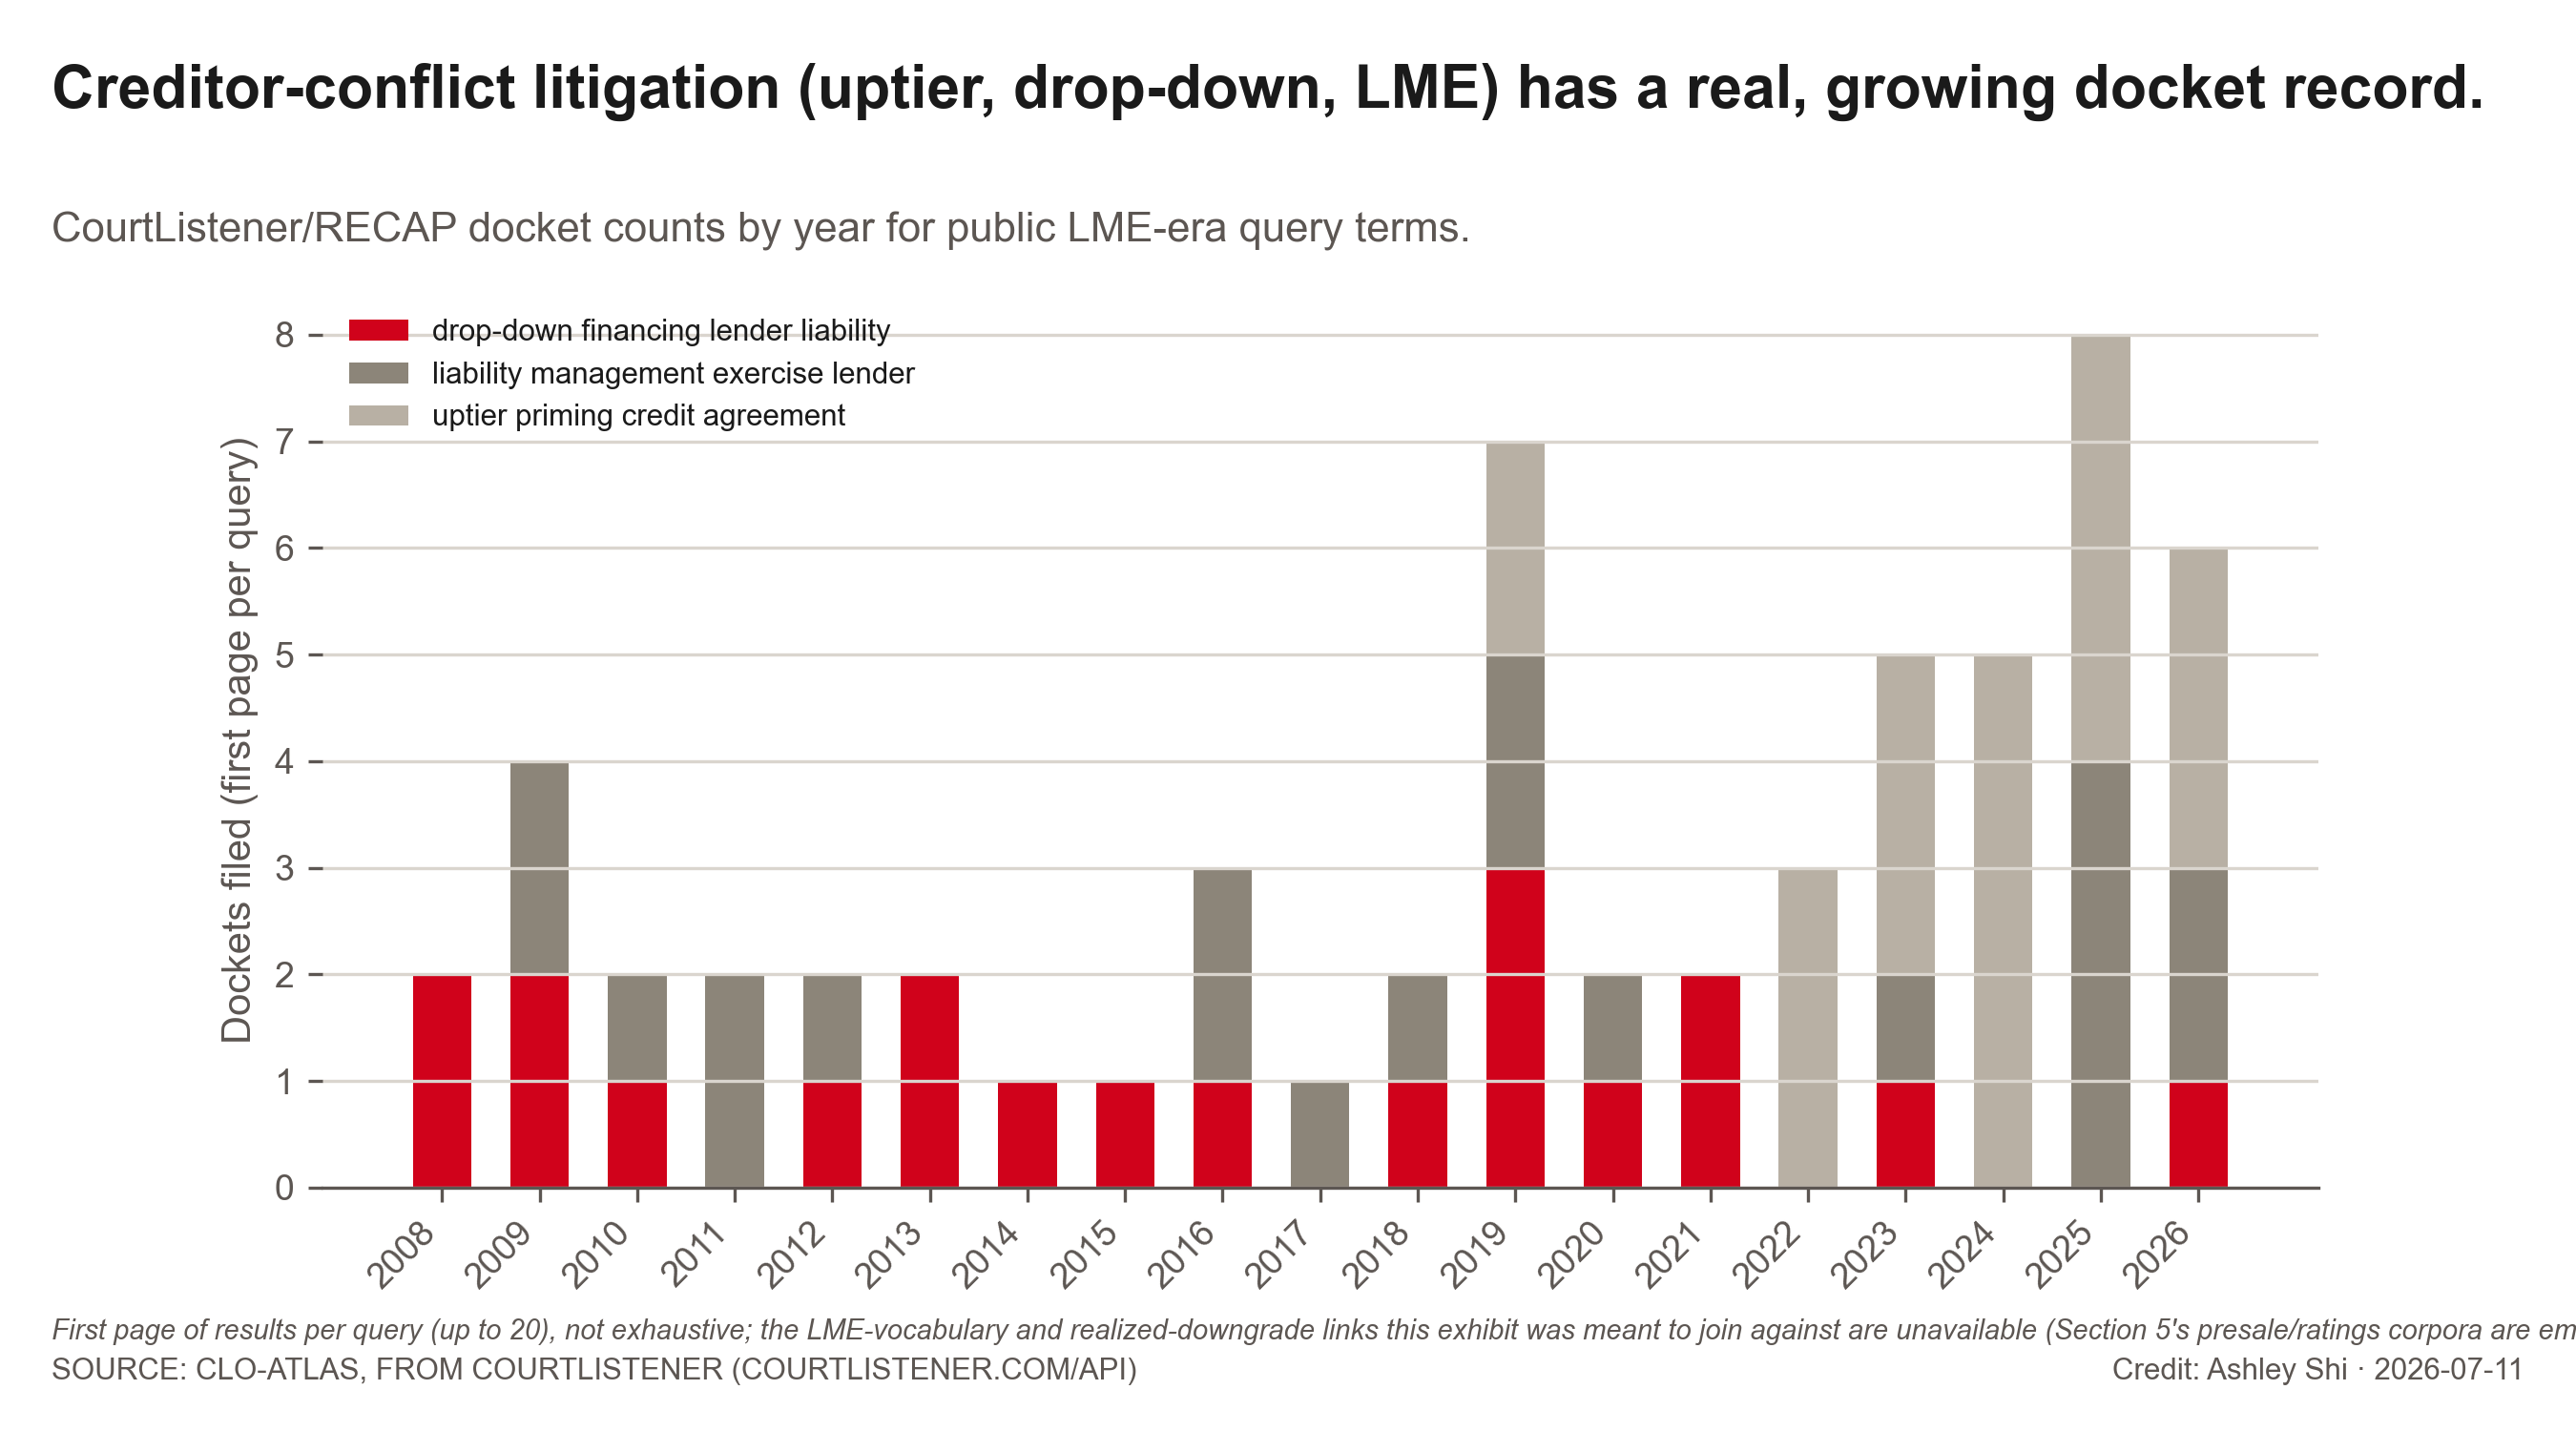

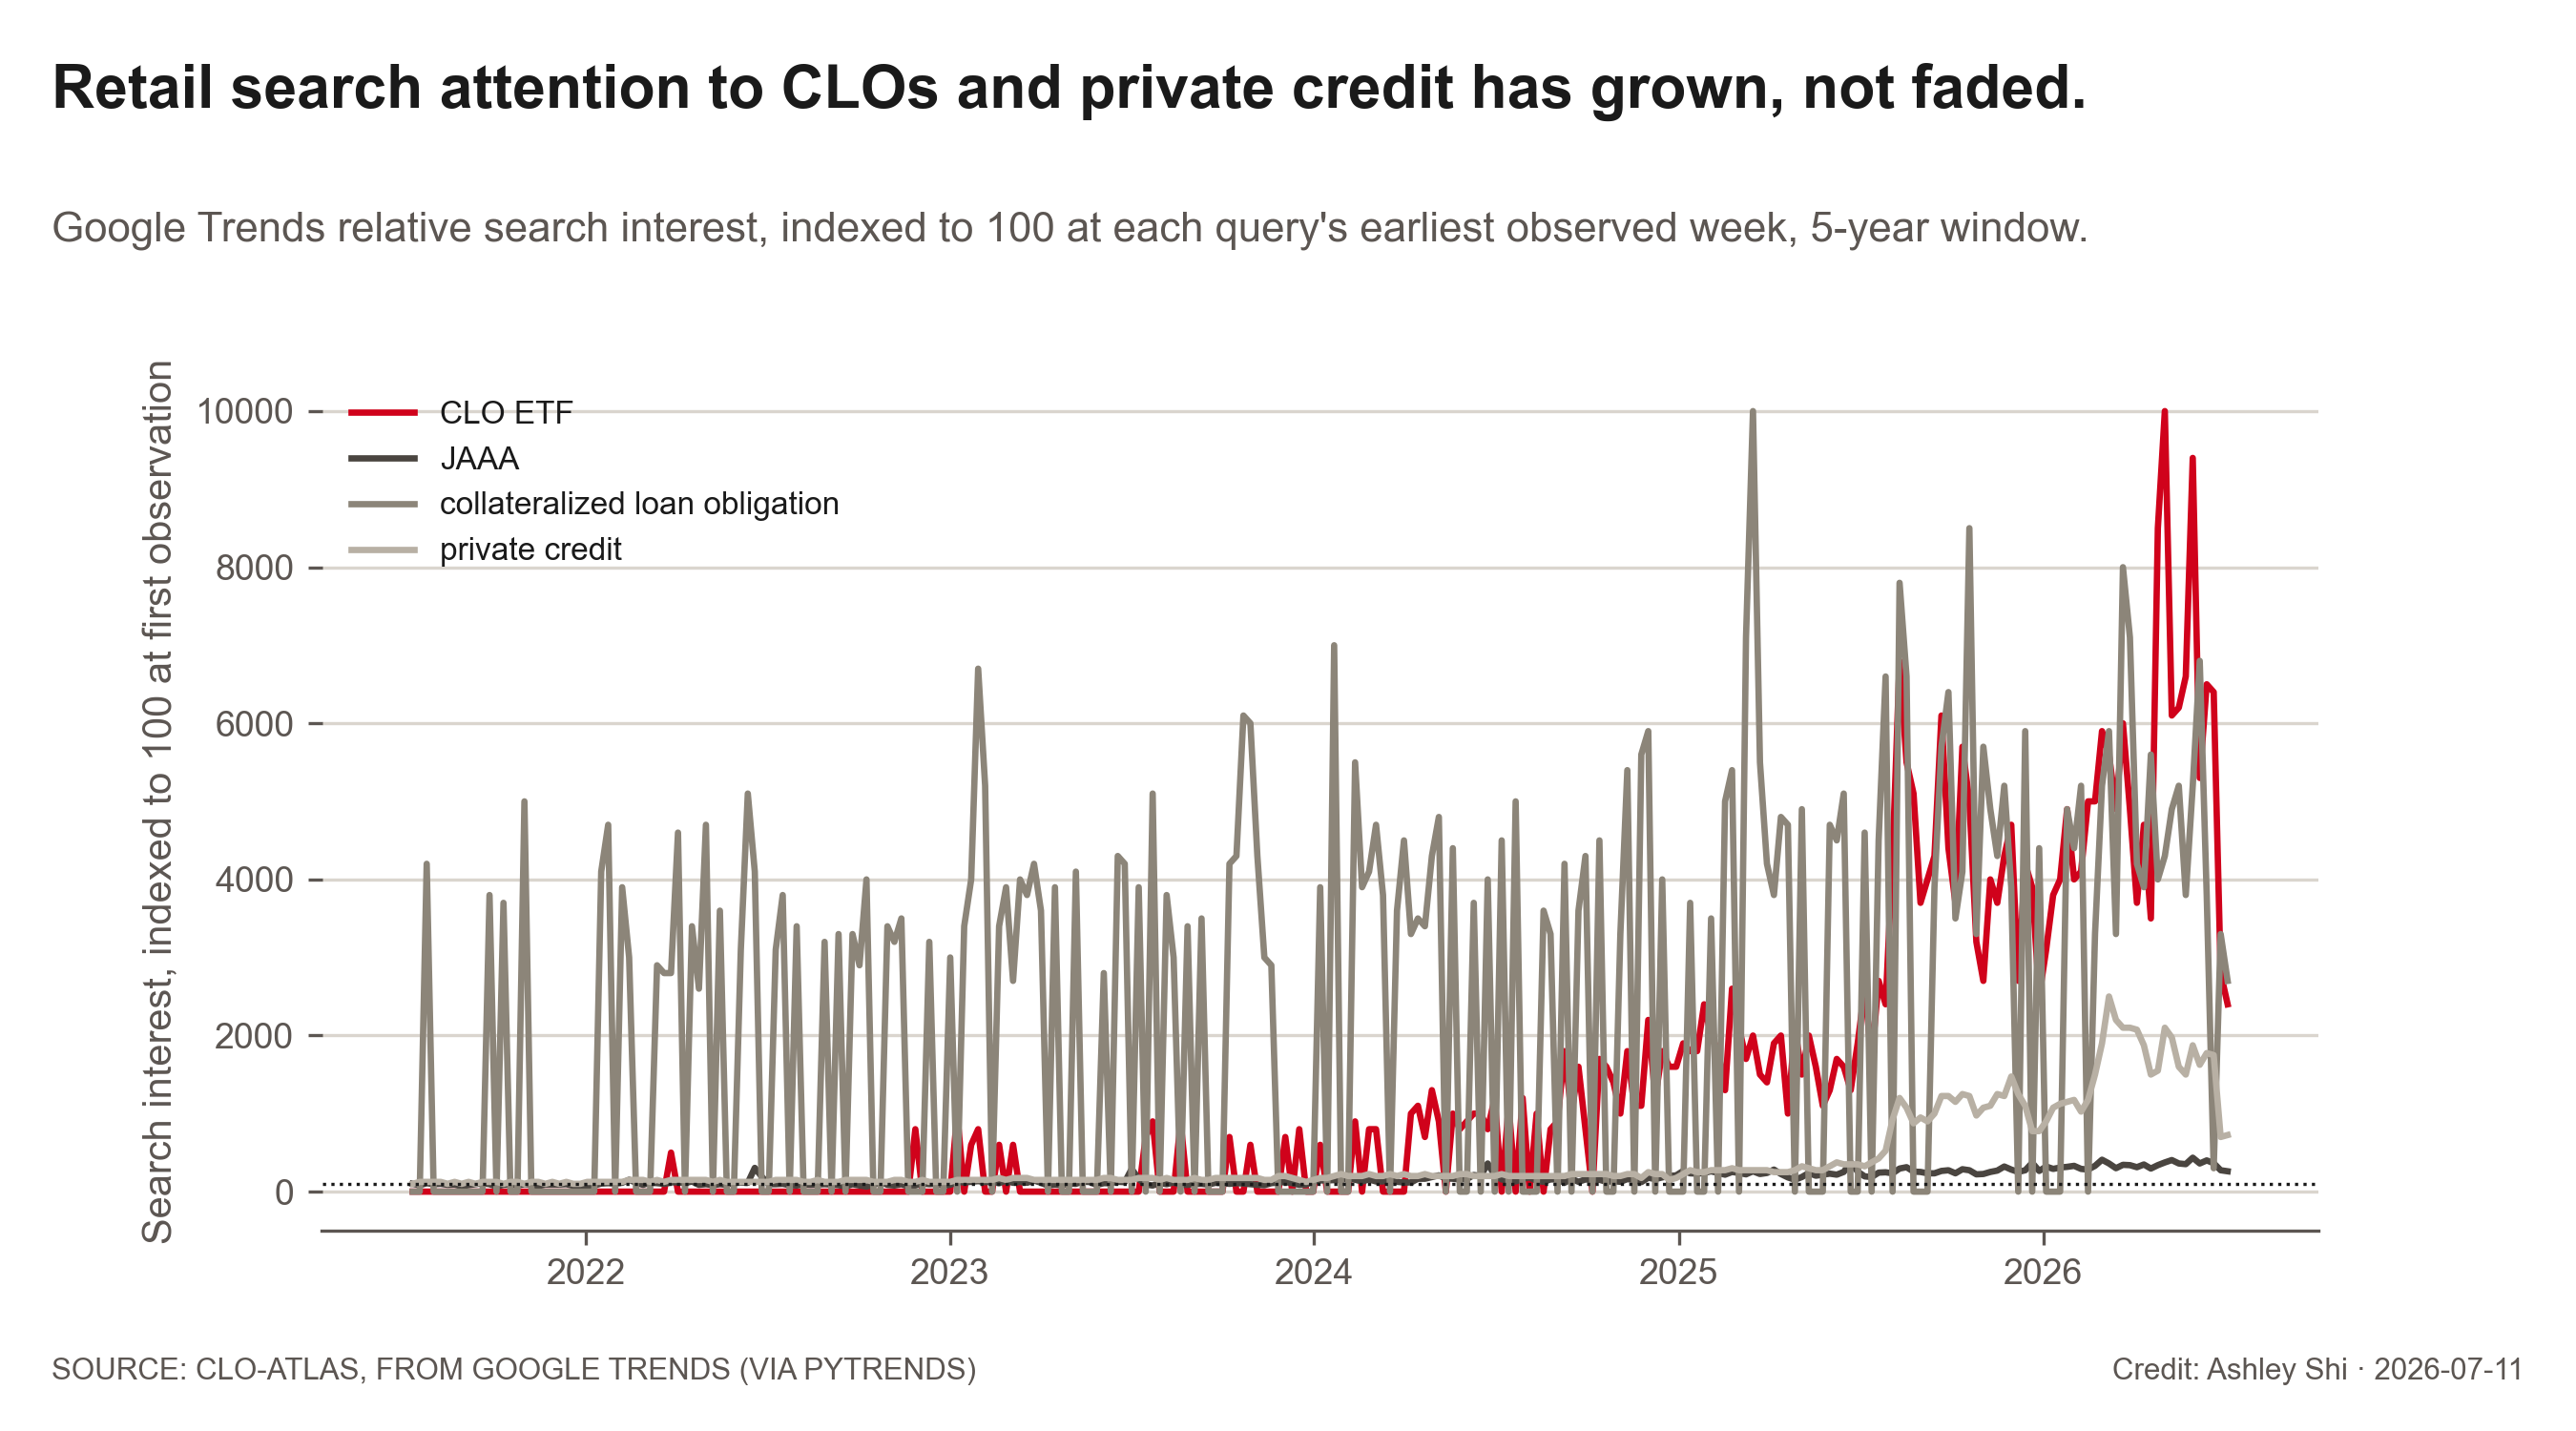

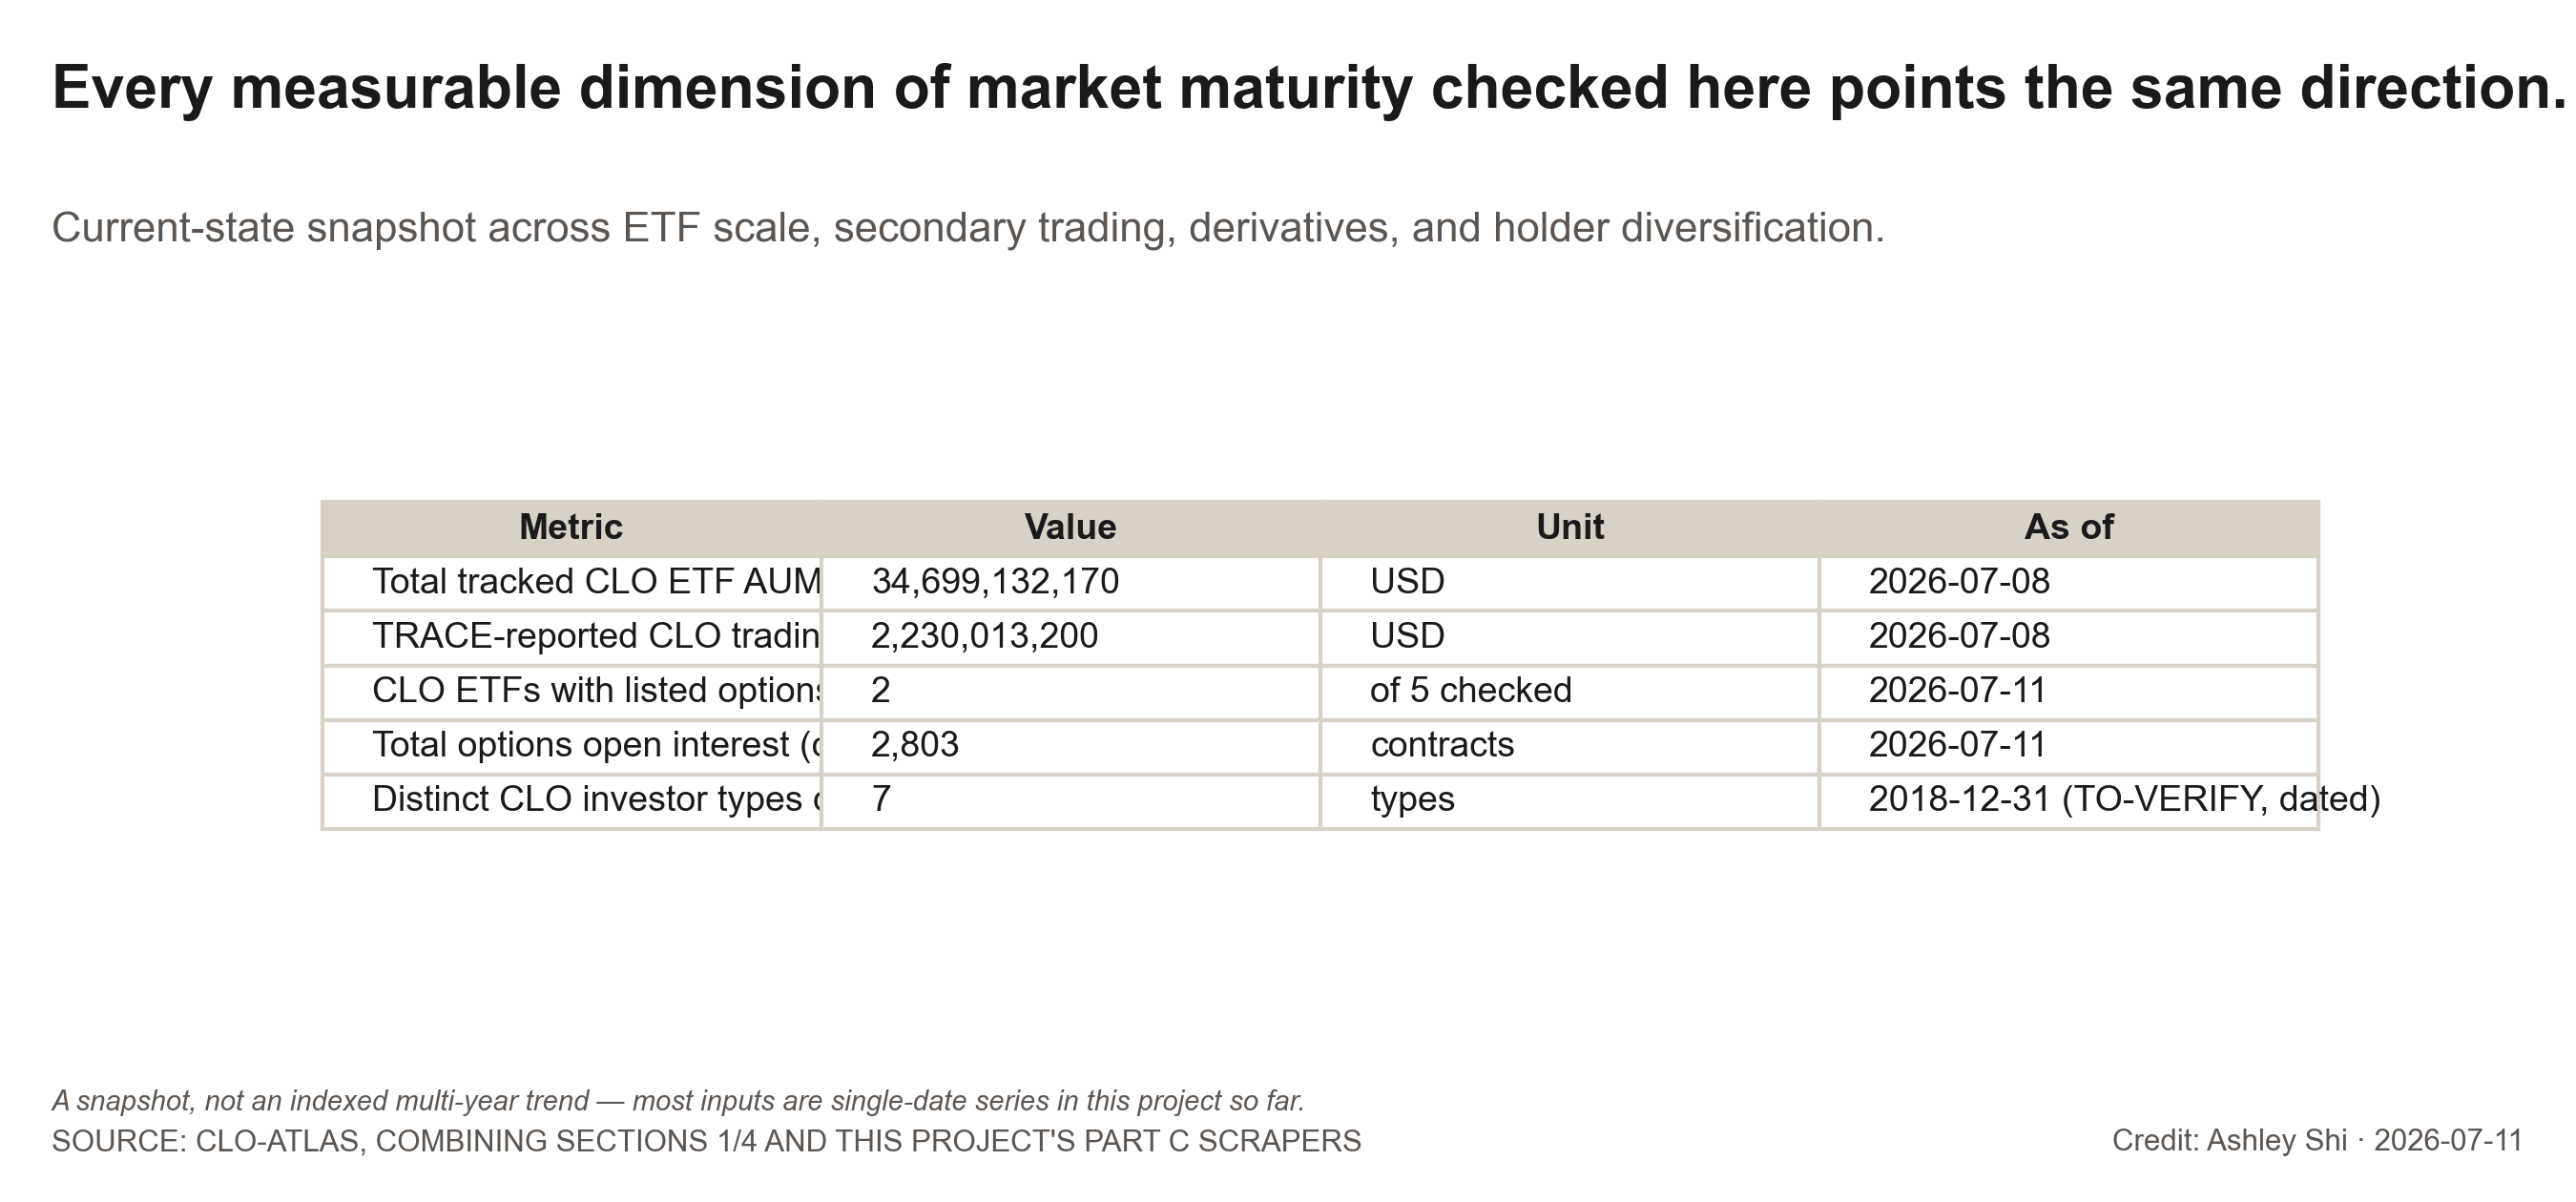

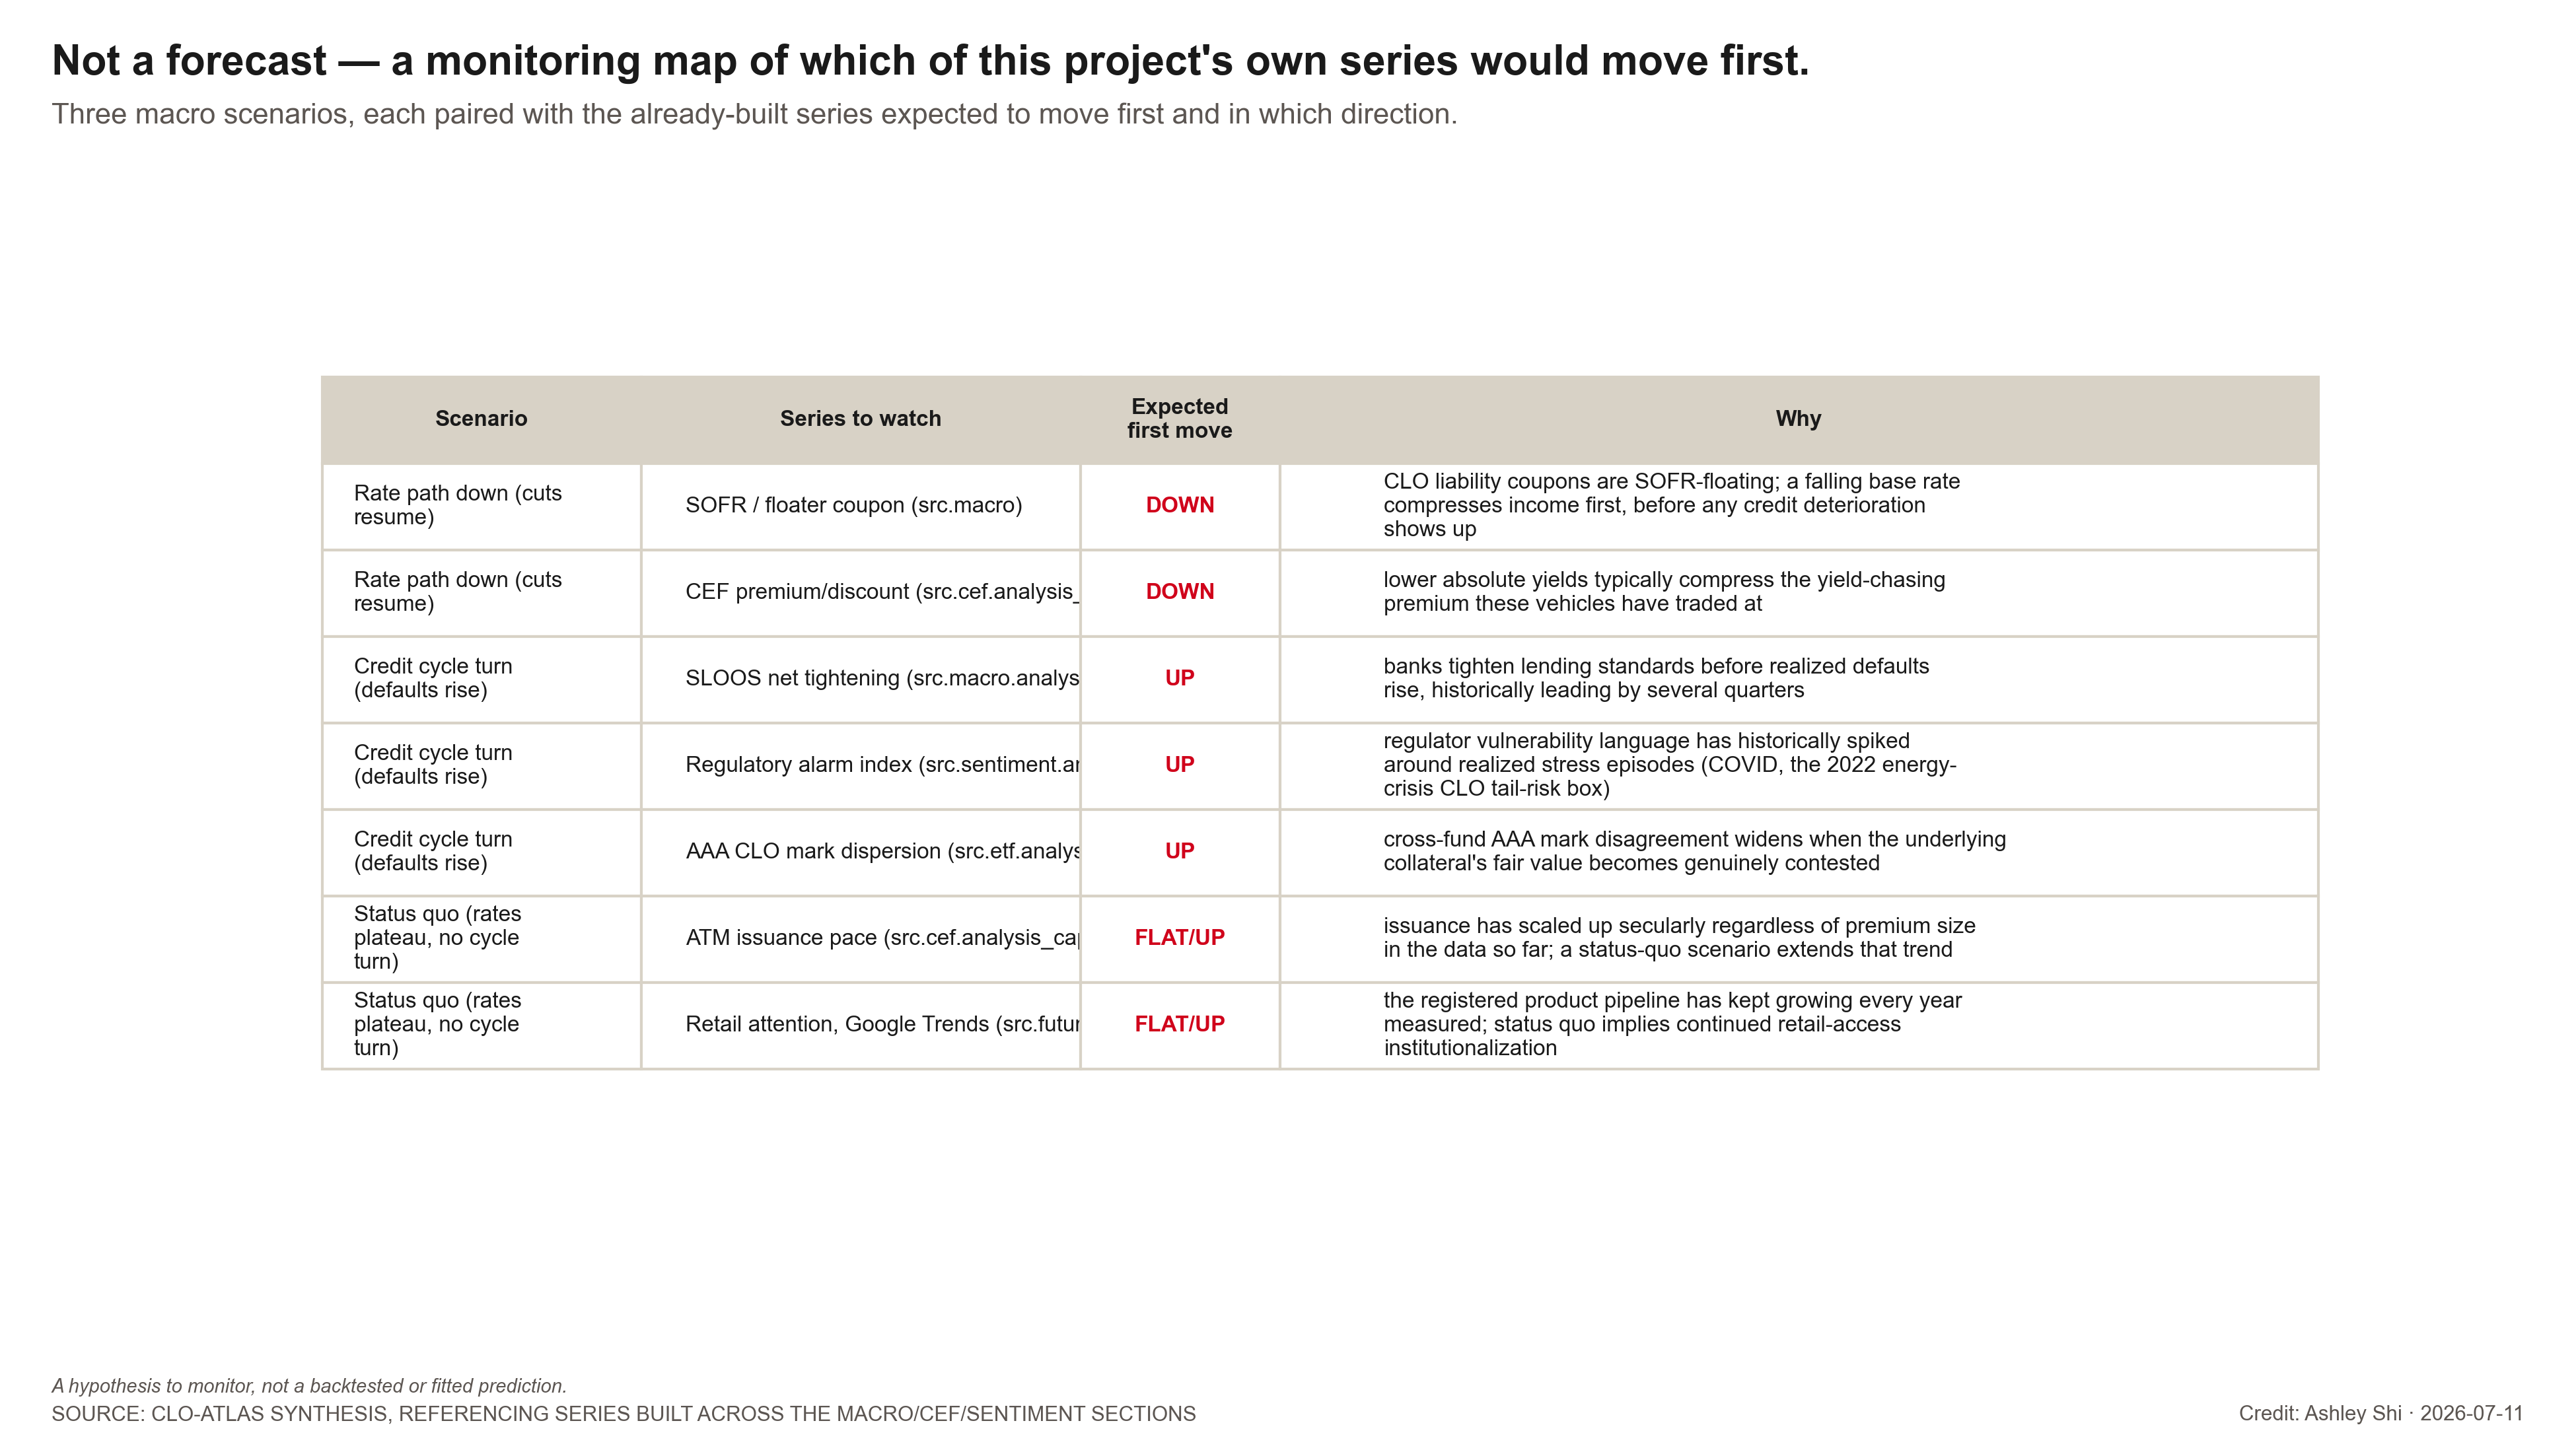

In [5]:
EXHIBITS = [
    "viz_registrations_by_year",
    "viz_mm_share_proxy",
    "viz_litigation_intensity",
    "viz_attention_indexed", "viz_scorecard_table",
    "viz_scenario_watchlist",
]
for name in EXHIBITS:
    path = pathlib.Path("../figures") / f"{name}.png"
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f"[skipped — not generated this run] {name}")


## VERIFIED / TO-VERIFY ledger

Every number appearing in this section's exhibits, including the composition-shift and legal-regime chains' stated gaps.

In [6]:
future_ledger = ledger.run()
future_ledger


,value,computation_or_citation,as_of,tag
0,293 CLO-mentioning fund-registration filings a...,"analysis_pipeline.registrations_by_year(), fro...",n/a,VERIFIED
1,102 distinct sponsors observed in the registra...,analysis_pipeline.sponsor_entry_order(),n/a,VERIFIED
2,MM-shelf share proxy: 2 fund-period observatio...,analysis_composition_shift.mm_share_trend() — ...,n/a,VERIFIED
3,60 LME-era dockets found across 3 query terms,"analysis_legal_regime.litigation_intensity(), ...",n/a,VERIFIED
4,Litigation intensity: measured,CourtListener docket counts by year (first pag...,n/a,VERIFIED
5,-> LME vocabulary in presales/ratings: GAP,Section 5 presale corpus is empty (S&P Akamai-...,n/a,GAP — not plotted
6,-> realized downgrade actions: GAP,ratings_transitions_monthly.parquet is empty f...,n/a,GAP — not plotted
7,Total tracked CLO ETF AUM: 34699132170.0,analysis_maturation_scorecard.snapshot_table(),2026-07-08,VERIFIED
8,TRACE-reported CLO trading volume: 2230013200.0,analysis_maturation_scorecard.snapshot_table(),2026-07-08,VERIFIED
9,CLO ETFs with listed options: 2.0,analysis_maturation_scorecard.snapshot_table(),2026-07-11,VERIFIED
